In [1]:
# ============================================================
# CELDA 1 — Imports y carga de modelos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Rutas
BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
MODELS    = os.path.join(BASE, 'src', 'models')
REPORTS   = os.path.join(BASE, 'reports')

# Carga dataset
df = pd.read_csv(os.path.join(PROCESSED, 'listings_clean.csv'), low_memory=False)

# Carga modelo XGBoost y encoders
with open(os.path.join(MODELS, 'xgboost_ocupacion.pkl'), 'rb') as f:
    modelo_xgb = pickle.load(f)
with open(os.path.join(MODELS, 'encoders_ocupacion.pkl'), 'rb') as f:
    encoders_xgb = pickle.load(f)

# Carga modelo Random Forest y encoders
with open(os.path.join(MODELS, 'rf_precio.pkl'), 'rb') as f:
    modelo_rf = pickle.load(f)
with open(os.path.join(MODELS, 'encoders_rf_precio.pkl'), 'rb') as f:
    encoders_rf = pickle.load(f)

print("Modelos cargados correctamente")
print(f"Dataset: {df.shape[0]:,} filas | {df.shape[1]} columnas")

Modelos cargados correctamente
Dataset: 69,142 filas | 33 columnas


In [3]:
# ============================================================
# CELDA 2 — Preparación de datos para SHAP
# ============================================================

from sklearn.preprocessing import LabelEncoder

le_ciudad_xgb = encoders_xgb['le_ciudad']
le_barrio_xgb = encoders_xgb['le_barrio']
le_room_xgb   = encoders_xgb['le_room']

FEATURES_XGB = encoders_xgb['features']

df_xgb = df.copy()

df_xgb['ciudad_enc'] = df_xgb['ciudad'].apply(
    lambda x: int(le_ciudad_xgb.transform([x])[0]) if x in le_ciudad_xgb.classes_ else 0)
df_xgb['barrio_enc'] = df_xgb['neighbourhood_cleansed'].apply(
    lambda x: int(le_barrio_xgb.transform([x])[0]) if x in le_barrio_xgb.classes_ else 0)
df_xgb['room_enc'] = df_xgb['room_type'].apply(
    lambda x: int(le_room_xgb.transform([x])[0]) if x in le_room_xgb.classes_ else 0)

df_xgb_clean = df_xgb[FEATURES_XGB + ['ocupacion']].dropna()
X_xgb = df_xgb_clean[FEATURES_XGB]
y_xgb = df_xgb_clean['ocupacion']

X_shap_xgb = X_xgb.sample(1000, random_state=42)

print(f"Dataset SHAP XGBoost: {X_shap_xgb.shape}")
print(f"Features: {FEATURES_XGB}")

Dataset SHAP XGBoost: (1000, 17)
Features: ['ciudad_enc', 'barrio_enc', 'room_enc', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 'price', 'minimum_nights', 'availability_365', 'host_is_superhost', 'host_listings_count', 'instant_bookable', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value']


In [4]:
# ============================================================
# CELDA 3 — Cálculo valores SHAP para XGBoost
# ============================================================

print("Calculando valores SHAP para XGBoost...")

# Explainer SHAP para XGBoost
explainer_xgb = shap.TreeExplainer(modelo_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_shap_xgb)

print(f"✅ SHAP calculado")
print(f"Shape valores SHAP: {shap_values_xgb.shape}")

# Nombres legibles para las features
feature_names_legibles = [
    'Ciudad', 'Barrio', 'Tipo alojamiento',
    'Huespedes', 'Habitaciones', 'Banos', 'Camas',
    'Precio/noche', 'Noches minimas', 'Disponibilidad anual',
    'Superhost', 'Anuncios host', 'Reserva instantanea',
    'Valoracion general', 'Limpieza', 'Ubicacion', 'Calidad-precio'
]

print(f"\nTop 5 variables mas importantes (SHAP):")
importancia_shap = np.abs(shap_values_xgb).mean(axis=0)
for i in np.argsort(importancia_shap)[::-1][:5]:
    print(f"  {feature_names_legibles[i]}: {importancia_shap[i]:.4f}")

Calculando valores SHAP para XGBoost...
✅ SHAP calculado
Shape valores SHAP: (1000, 17)

Top 5 variables mas importantes (SHAP):
  Noches minimas: 0.0463
  Ubicacion: 0.0442
  Superhost: 0.0373
  Valoracion general: 0.0362
  Calidad-precio: 0.0356


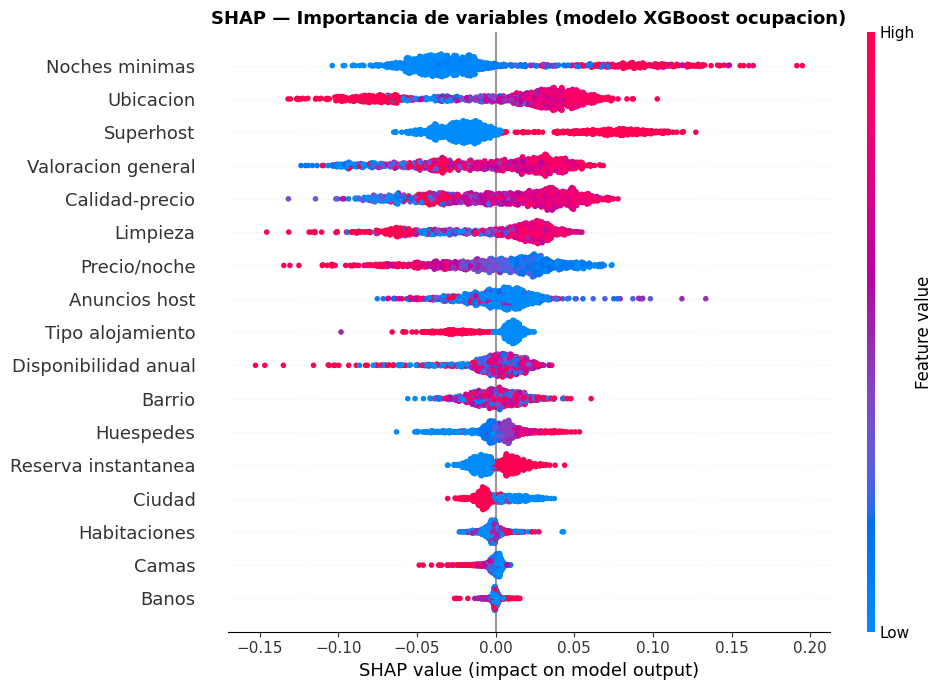

✅ Grafico beeswarm guardado


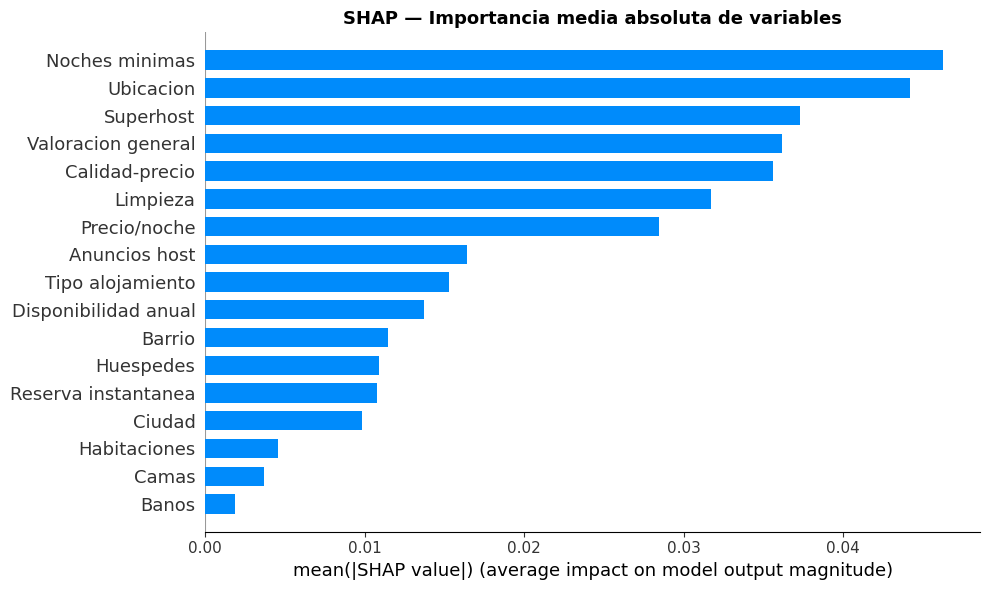

✅ Grafico barras guardado


In [5]:
# ============================================================
# CELDA 4 — Gráficos SHAP
# ============================================================

X_shap_named = X_shap_xgb.copy()
X_shap_named.columns = feature_names_legibles

# Gráfico 1: Importancia global (beeswarm)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_xgb,
    X_shap_named,
    show=False,
    plot_size=None
)
plt.title("SHAP — Importancia de variables (modelo XGBoost ocupacion)", 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap_xgb_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico beeswarm guardado")

# Gráfico 2: Importancia media (barras)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb,
    X_shap_named,
    plot_type='bar',
    show=False,
    plot_size=None
)
plt.title("SHAP — Importancia media absoluta de variables", 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap_xgb_barras.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico barras guardado")

In [6]:
# ============================================================
# CELDA 5 — Guardado valores SHAP
# ============================================================

shap_data = {
    'shap_values_xgb':    shap_values_xgb,
    'X_shap_xgb':         X_shap_xgb,
    'feature_names':      feature_names_legibles,
    'explainer_xgb':      explainer_xgb,
}

ruta_shap = os.path.join(MODELS, 'shap_xgb.pkl')
with open(ruta_shap, 'wb') as f:
    pickle.dump(shap_data, f)

tam = os.path.getsize(ruta_shap) / (1024*1024)
print(f"✅ Valores SHAP guardados: {ruta_shap}")
print(f"   Tamaño: {tam:.1f} MB")

✅ Valores SHAP guardados: /Users/ivannavarrosuero/tfm_vut/src/models/shap_xgb.pkl
   Tamaño: 7.1 MB
